<a href="https://colab.research.google.com/github/Manmeets2/workplace/blob/main/Customer_Purchase_Behavior_%26_Revenue_Leakage_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Analyze customer purchase behavior and identify potential revenue leakage using the data from "/content/OnlineRetail.csv".

## Load and Inspect Data

### Subtask:
Load the customer purchase data into a DataFrame and perform an initial inspection, including viewing the first few rows, checking data types, and looking for missing values. This will help us understand the available information.


**Reasoning**:
To begin the data inspection, I will import the pandas library, load the specified CSV file into a DataFrame, display its first few rows, check its data types and non-null values, and then summarize any missing values per column. This covers all the initial inspection steps requested.



**Reasoning**:
The previous code failed with a `UnicodeDecodeError` because the CSV file is likely not encoded in 'utf-8'. I will specify `encoding='latin1'` when reading the CSV, as this is a common encoding for such datasets and often resolves this type of error, and retain all other steps as they are still relevant for initial data inspection.



In [2]:
import pandas as pd

# Load the CSV file into a DataFrame, specifying 'latin1' encoding
df = pd.read_csv('/content/OnlineRetail.csv', encoding='latin1')
print("DataFrame loaded successfully.")

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the DataFrame:")
print(df.head())

# Print the concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Print the number of missing values for each column
print("\nMissing values per column:")
print(df.isnull().sum())

DataFrame loaded successfully.

First 5 rows of the DataFrame:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150444 entries, 0 to 150443
Data columns (total 8 columns):
 #   Column       Non-N

## Analyze Customer Purchase Behavior

### Subtask:
Examine various aspects of customer purchase behavior, such as total purchases per customer, average order value, purchase frequency, and popular products or categories. This will provide insights into how customers interact with your products/services.


**Reasoning**:
The first instructions involve converting 'InvoiceDate' to datetime, removing rows with missing 'CustomerID', and creating a 'TotalPrice' column. These are all crucial data preparation steps to enable the subsequent analysis of customer behavior.



In [3]:
import numpy as np

# 1. Convert 'InvoiceDate' to datetime objects
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Converted 'InvoiceDate' to datetime objects.")

# 2. Remove rows where 'CustomerID' is missing
df.dropna(subset=['CustomerID'], inplace=True)
print("Removed rows with missing 'CustomerID'.")

# Convert CustomerID to integer type as it's often used as an identifier and float isn't ideal
df['CustomerID'] = df['CustomerID'].astype(int)
print("Converted 'CustomerID' to integer type.")

# 3. Create a new column named 'TotalPrice'
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print("Created 'TotalPrice' column.")

# Display the first few rows with the new TotalPrice column and check info again
print("\nDataFrame after initial processing (head):")
print(df.head())
print("\nDataFrame Info after processing:")
df.info()
print("\nMissing values per column after processing:")
print(df.isnull().sum())

Converted 'InvoiceDate' to datetime objects.
Removed rows with missing 'CustomerID'.
Converted 'CustomerID' to integer type.
Created 'TotalPrice' column.

DataFrame after initial processing (head):
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39       17850  United Kingdom       20

**Reasoning**:
Now that the data is prepared, I will proceed with calculating the total purchases per customer, average order value per customer, purchase frequency per customer, and identifying popular products, as specified in the subtask instructions.



In [4]:
print("\n--- Customer Purchase Behavior Analysis ---")

# 4. Group by 'CustomerID' and sum 'TotalPrice' for total amount spent
total_purchase_per_customer = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)
print("\nTotal purchase per customer (Top 10):\n")
print(total_purchase_per_customer.head(10))

# 5. Calculate the average order value per customer
# First, calculate the total price per invoice for each customer
price_per_invoice = df.groupby(['CustomerID', 'InvoiceNo'])['TotalPrice'].sum().reset_index()
average_order_value_per_customer = price_per_invoice.groupby('CustomerID')['TotalPrice'].mean().sort_values(ascending=False)
print("\nAverage order value per customer (Top 10):\n")
print(average_order_value_per_customer.head(10))

# 6. Count the number of unique 'InvoiceNo' for purchase frequency per customer
purchase_frequency_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)
print("\nPurchase frequency per customer (number of unique orders, Top 10):\n")
print(purchase_frequency_per_customer.head(10))

# 7. Determine the most frequently purchased products by grouping 'Description' and summing 'Quantity'
popular_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)
print("\nMost frequently purchased products (Top 10):\n")
print(popular_products.head(10))



--- Customer Purchase Behavior Analysis ---

Total purchase per customer (Top 10):

CustomerID
14646    81567.62
18102    45279.41
12415    38024.04
14156    35119.44
17450    33017.46
15061    26889.76
17511    25357.89
14911    23363.26
15769    23181.48
15749    22998.40
Name: TotalPrice, dtype: float64

Average order value per customer (Top 10):

CustomerID
15749    11499.200000
14088     7544.910000
12415     6337.340000
18102     5659.926250
14646     4798.095294
12435     3978.990000
15125     3840.880000
13340     3678.030000
17450     3668.606667
12451     2919.510000
Name: TotalPrice, dtype: float64

Purchase frequency per customer (number of unique orders, Top 10):

CustomerID
12748    61
14911    51
14606    51
15311    45
17841    43
13089    39
17850    35
15061    31
16422    30
12971    30
Name: InvoiceNo, dtype: int64

Most frequently purchased products (Top 10):

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     17140
JUMBO BAG RED RETROSPOT               13249
PACK 

## Identify Potential Revenue Leakage Areas

### Subtask:
Based on the available data, identify potential areas where revenue might be leaking. This could involve analyzing customer churn indicators, understanding reasons for incomplete purchases, or identifying segments with low engagement or repeat purchase rates. This step will require a clear definition of 'revenue leakage' based on the dataset's features.


## Identify Potential Revenue Leakage Areas

### Subtask:
Based on the available data, identify potential areas where revenue might be leaking. This could involve analyzing customer churn indicators, understanding reasons for incomplete purchases, or identifying segments with low engagement or repeat purchase rates. This step will require a clear definition of 'revenue leakage' based on the dataset's features.

#### Instructions
1. Identify all transactions where 'Quantity' is negative, as these represent returns or cancellations. Create a new DataFrame or Series containing these transactions.
2. Calculate the total monetary value of these returned/canceled items by summing their 'TotalPrice' column.
3. Identify the top 10 most returned/canceled products by grouping the negative quantity transactions by 'Description' and summing their absolute 'Quantity'.
4. Identify customers with a net negative total purchase amount, meaning their returns or cancellations have exceeded their purchases. List the top 10 such customers based on their total negative 'TotalPrice'.

**Reasoning**:
The subtask requires identifying transactions with negative quantities to understand returns and cancellations, which is a key aspect of revenue leakage. I will start by filtering the DataFrame to isolate these records.



In [5]:
print("\n--- Identifying Revenue Leakage Areas ---")

# 1. Identify all transactions where 'Quantity' is negative (returns/cancellations)
negative_quantity_transactions = df[df['Quantity'] < 0].copy()
print("Identified transactions with negative quantities.")

# Display some information about these transactions
print("\nNegative Quantity Transactions (head):\n")
print(negative_quantity_transactions.head())
print("\nNegative Quantity Transactions Info:\n")
negative_quantity_transactions.info()


--- Identifying Revenue Leakage Areas ---
Identified transactions with negative quantities.

Negative Quantity Transactions (head):

    InvoiceNo StockCode                       Description  Quantity  \
141   C536379         D                          Discount        -1   
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1   
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12   
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24   
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24   

            InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
141 2010-12-01 09:41:00      27.50       14527  United Kingdom      -27.50  
154 2010-12-01 09:49:00       4.65       15311  United Kingdom       -4.65  
235 2010-12-01 10:24:00       1.65       17548  United Kingdom      -19.80  
236 2010-12-01 10:24:00       0.29       17548  United Kingdom       -6.96  
237 2010-12-01 10:24:00       0.29       17548  United

**Reasoning**:
Now that the transactions with negative quantities have been identified, the next step is to calculate the total monetary value of these returned or canceled items by summing their 'TotalPrice' column, as per the subtask instructions.



In [6]:
print('\n--- Calculating Total Monetary Value of Returns/Cancellations ---')

# 2. Calculate the total monetary value of these returned/canceled items
total_returned_value = negative_quantity_transactions['TotalPrice'].sum()
print(f"Total monetary value of returned/canceled items: £{total_returned_value:,.2f}")


--- Calculating Total Monetary Value of Returns/Cancellations ---
Total monetary value of returned/canceled items: £-150,311.42


**Reasoning**:
Following the subtask instructions, I will now identify the top 10 most returned or canceled products by grouping the `negative_quantity_transactions` by 'Description' and summing the absolute value of their 'Quantity'.



In [7]:
print('\n--- Identifying Top 10 Most Returned/Canceled Products ---')

# 3. Identify the top 10 most returned/canceled products by grouping the negative quantity transactions
#    by 'Description' and summing their absolute 'Quantity'.
top_returned_products = negative_quantity_transactions.groupby('Description')['Quantity'].sum().abs().sort_values(ascending=False)
print('\nTop 10 most returned/canceled products (by absolute quantity):\n')
print(top_returned_products.head(10))


--- Identifying Top 10 Most Returned/Canceled Products ---

Top 10 most returned/canceled products (by absolute quantity):

Description
MEDIUM CERAMIC TOP STORAGE JAR         74215
ROTATING SILVER ANGELS T-LIGHT HLDR     9366
Discount                                 737
ASSORTED COLOURS SILK FAN                648
ROUND SNACK BOXES SET OF 4 FRUITS        634
Manual                                   576
WHITE HANGING HEART T-LIGHT HOLDER       565
REGENCY CAKESTAND 3 TIER                 376
GOLD MINI TAPE MEASURE                   300
VICTORIAN SEWING KIT                     289
Name: Quantity, dtype: int64


**Reasoning**:
Now, to complete the subtask, I will identify customers whose total purchase amount is negative, indicating their returns/cancellations exceeded their purchases. I will use the previously calculated `total_purchase_per_customer` and filter for negative values, then sort to find the top 10.



In [8]:
print('\n--- Identifying Customers with Net Negative Purchase Amount ---')

# 4. Identify customers with a net negative total purchase amount
customers_net_negative_purchase = total_purchase_per_customer[total_purchase_per_customer < 0].sort_values()

print('\nTop 10 customers with a net negative total purchase amount (returns/cancellations exceeding purchases):\n')
print(customers_net_negative_purchase.head(10))


--- Identifying Customers with Net Negative Purchase Amount ---

Top 10 customers with a net negative total purchase amount (returns/cancellations exceeding purchases):

CustomerID
14213   -1192.20
12503   -1126.00
15823    -840.76
17603    -555.90
16252    -295.09
12666    -227.44
14304    -186.35
17307    -152.64
17548    -141.48
13958    -102.45
Name: TotalPrice, dtype: float64


## Visualize Key Findings

### Subtask:
Generate interactive visualizations to illustrate key findings from the customer purchase behavior and revenue leakage analysis. This may include charts showing customer segments, purchase trends, product popularity, or areas of potential leakage. Ensure plots include clear legends and labels.


**Reasoning**:
To begin the visualization of key findings, I will import the necessary plotting libraries, `matplotlib.pyplot` and `seaborn`. Then, I will generate bar plots for the top 10 customers by total purchase, average order value, and purchase frequency, as well as the top 10 most popular products, most returned products, and customers with net negative purchase amounts, ensuring all plots are properly labeled and displayed.



--- Visualizing Key Findings ---


/tmp/ipython-input-2247707014.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_purchase_per_customer.head(10).index.astype(str), y=total_purchase_per_customer.head(10).values, palette='viridis')


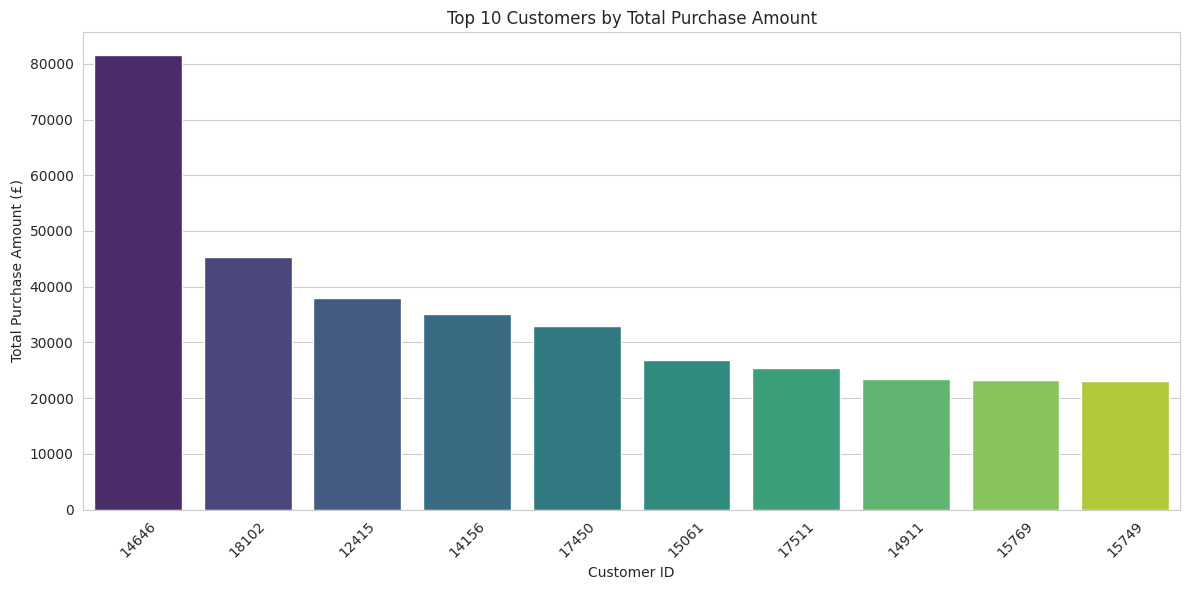

/tmp/ipython-input-2247707014.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_order_value_per_customer.head(10).index.astype(str), y=average_order_value_per_customer.head(10).values, palette='plasma')


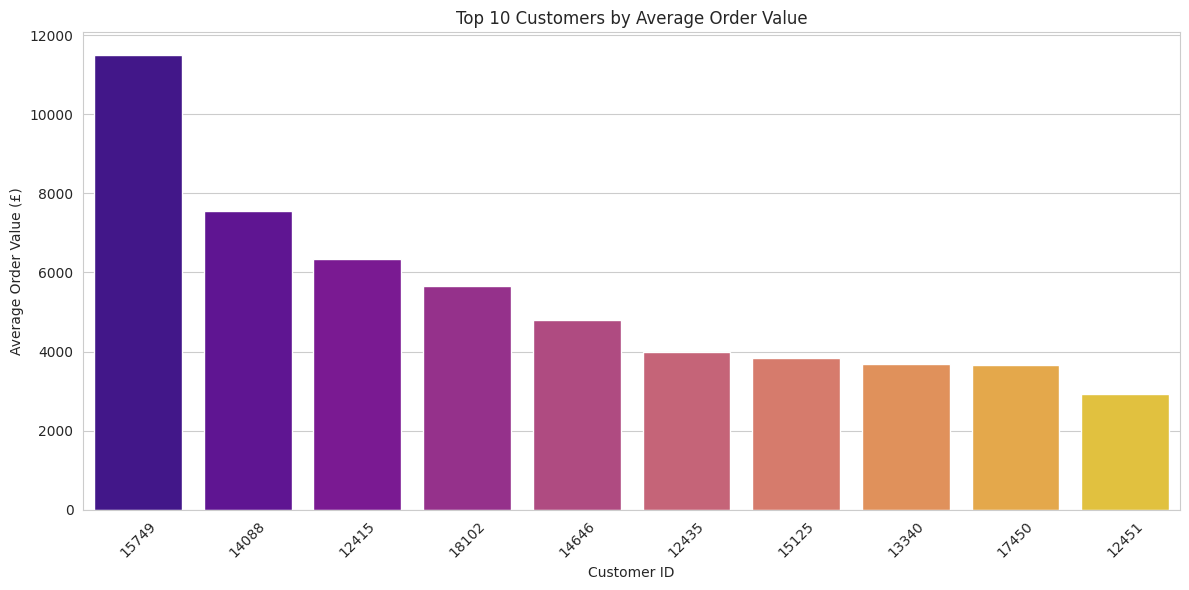

/tmp/ipython-input-2247707014.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=purchase_frequency_per_customer.head(10).index.astype(str), y=purchase_frequency_per_customer.head(10).values, palette='magma')


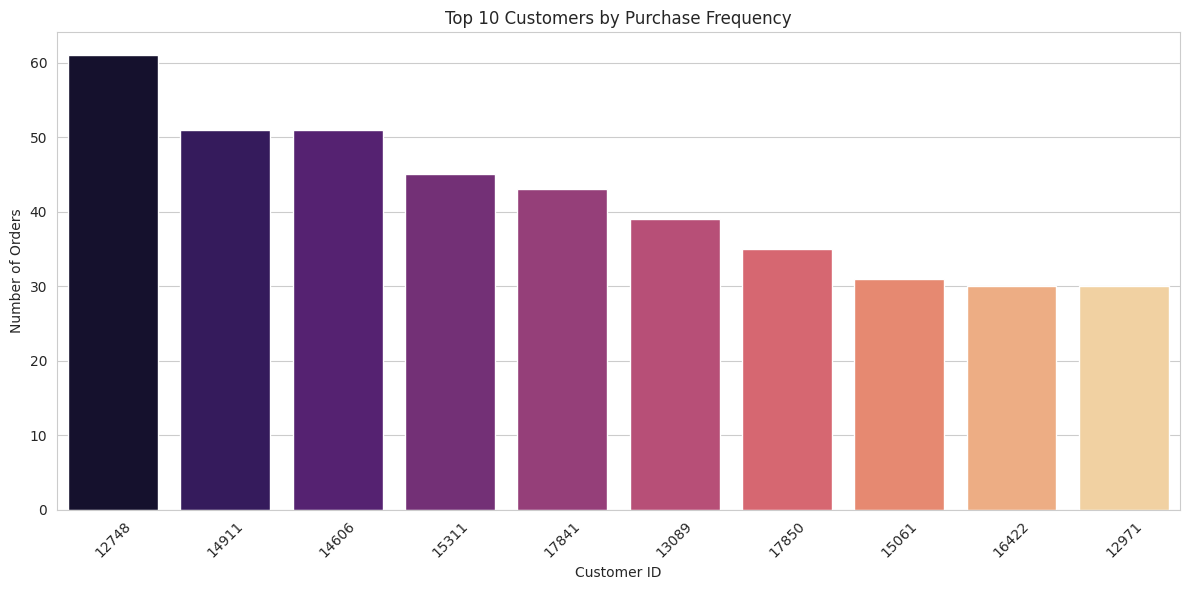

/tmp/ipython-input-2247707014.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popular_products.head(10).index, y=popular_products.head(10).values, palette='cividis')


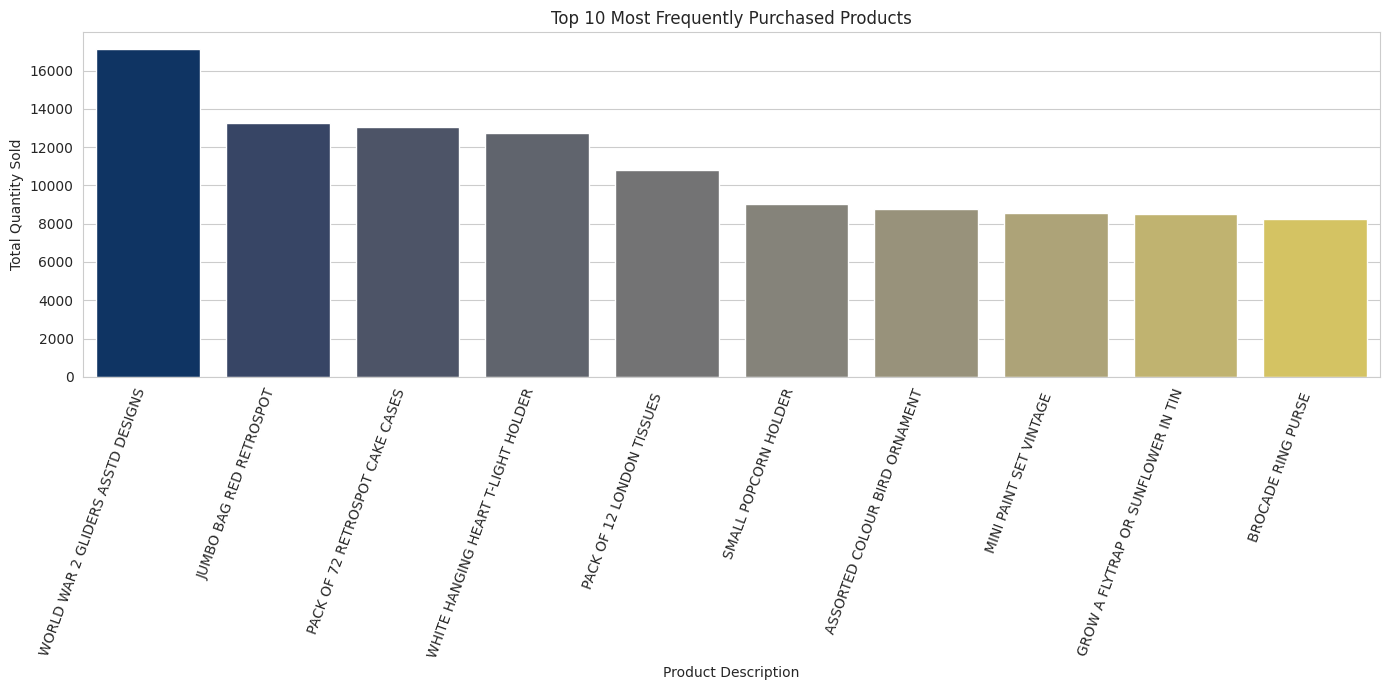

/tmp/ipython-input-2247707014.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_returned_products.head(10).index, y=top_returned_products.head(10).values, palette='inferno')


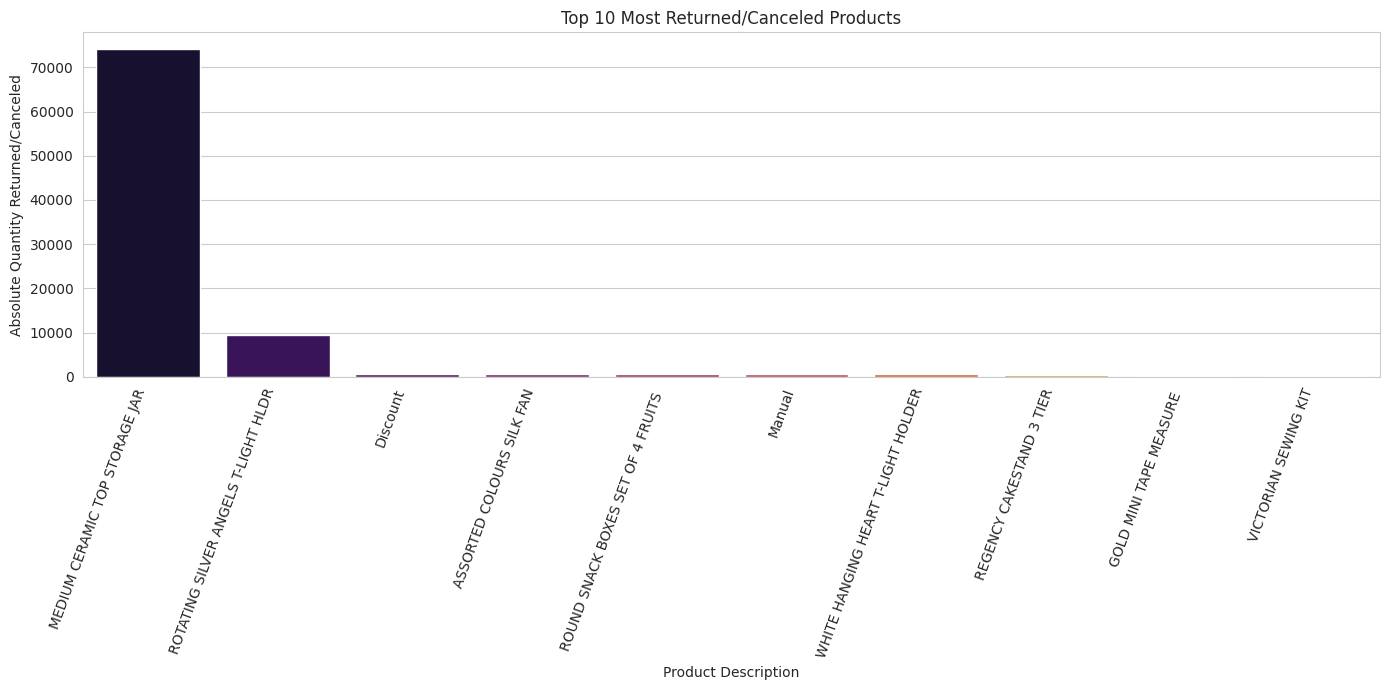

/tmp/ipython-input-2247707014.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customers_net_negative_purchase.head(10).index.astype(str), y=customers_net_negative_purchase.head(10).values, palette='rocket')


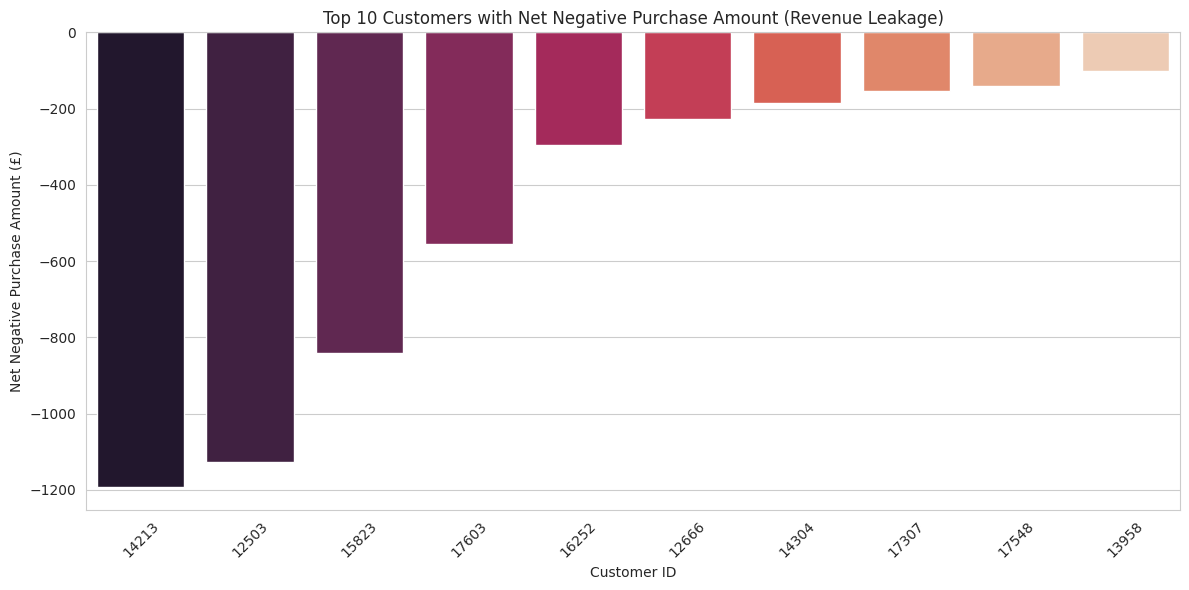

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

print("--- Visualizing Key Findings ---")

# 1. Bar plot for the top 10 customers by total purchase amount
plt.figure(figsize=(12, 6))
sns.barplot(x=total_purchase_per_customer.head(10).index.astype(str), y=total_purchase_per_customer.head(10).values, palette='viridis')
plt.title('Top 10 Customers by Total Purchase Amount')
plt.xlabel('Customer ID')
plt.ylabel('Total Purchase Amount (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Bar plot for the top 10 customers by average order value
plt.figure(figsize=(12, 6))
sns.barplot(x=average_order_value_per_customer.head(10).index.astype(str), y=average_order_value_per_customer.head(10).values, palette='plasma')
plt.title('Top 10 Customers by Average Order Value')
plt.xlabel('Customer ID')
plt.ylabel('Average Order Value (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Bar plot for the top 10 customers by purchase frequency
plt.figure(figsize=(12, 6))
sns.barplot(x=purchase_frequency_per_customer.head(10).index.astype(str), y=purchase_frequency_per_customer.head(10).values, palette='magma')
plt.title('Top 10 Customers by Purchase Frequency')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Bar plot for the top 10 most frequently purchased products
plt.figure(figsize=(14, 7))
sns.barplot(x=popular_products.head(10).index, y=popular_products.head(10).values, palette='cividis')
plt.title('Top 10 Most Frequently Purchased Products')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=70, ha='right') # Rotate for better readability
plt.tight_layout()
plt.show()

# 5. Bar plot for the top 10 most returned/canceled products
plt.figure(figsize=(14, 7))
sns.barplot(x=top_returned_products.head(10).index, y=top_returned_products.head(10).values, palette='inferno')
plt.title('Top 10 Most Returned/Canceled Products')
plt.xlabel('Product Description')
plt.ylabel('Absolute Quantity Returned/Canceled')
plt.xticks(rotation=70, ha='right') # Rotate for better readability
plt.tight_layout()
plt.show()

# 6. Bar plot for the top 10 customers with a net negative total purchase amount
plt.figure(figsize=(12, 6))
sns.barplot(x=customers_net_negative_purchase.head(10).index.astype(str), y=customers_net_negative_purchase.head(10).values, palette='rocket')
plt.title('Top 10 Customers with Net Negative Purchase Amount (Revenue Leakage)')
plt.xlabel('Customer ID')
plt.ylabel('Net Negative Purchase Amount (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated `FutureWarning` messages because the `palette` argument was used without specifying the `hue` argument in `seaborn.barplot`. To resolve this and explicitly adhere to the suggested fix from the warning, I will modify each `sns.barplot` call to include `hue` as the x-axis variable and set `legend=False`.



--- Visualizing Key Findings ---


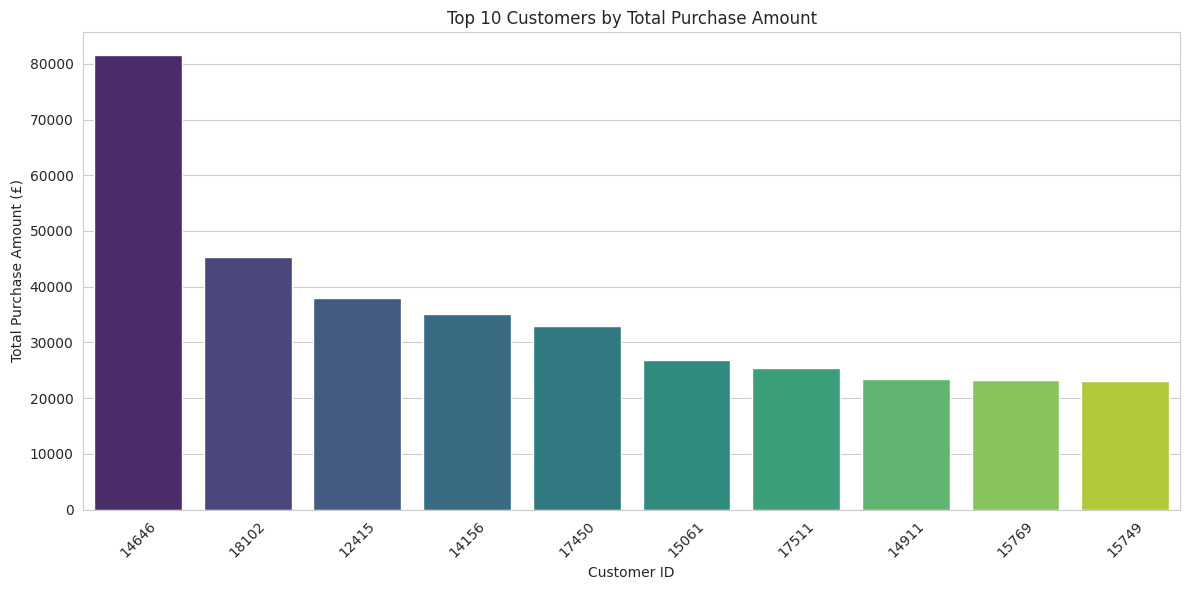

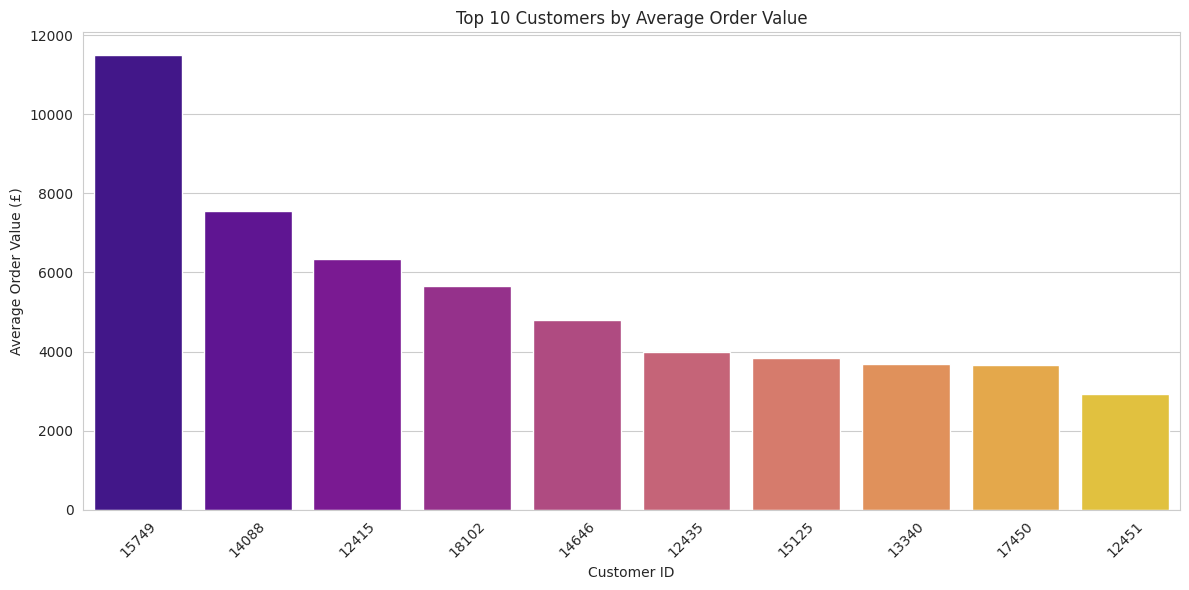

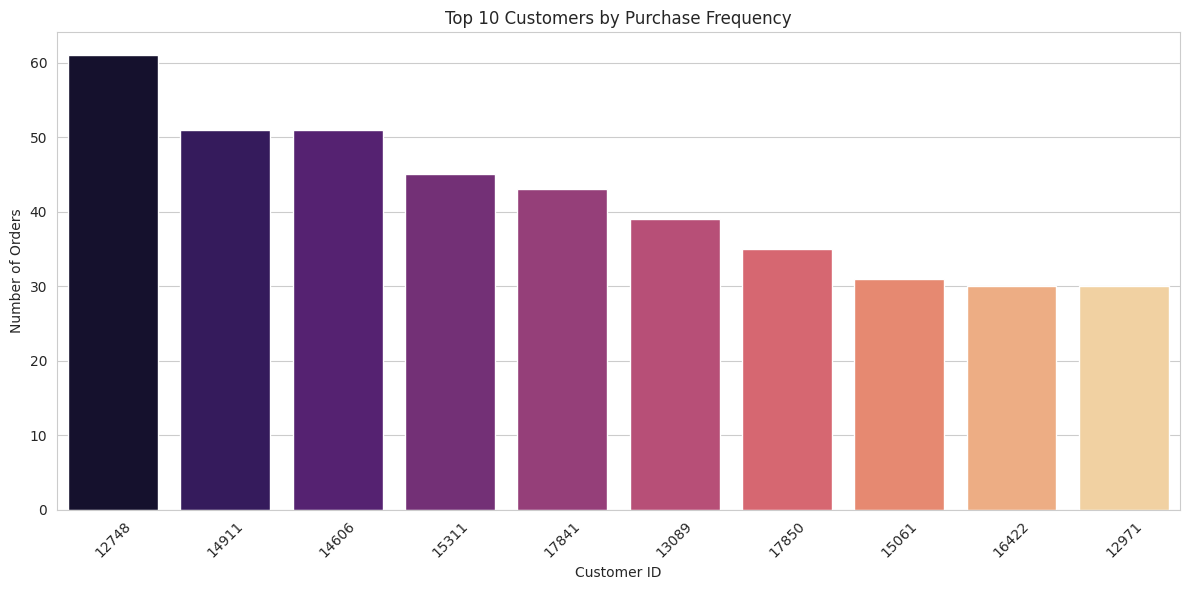

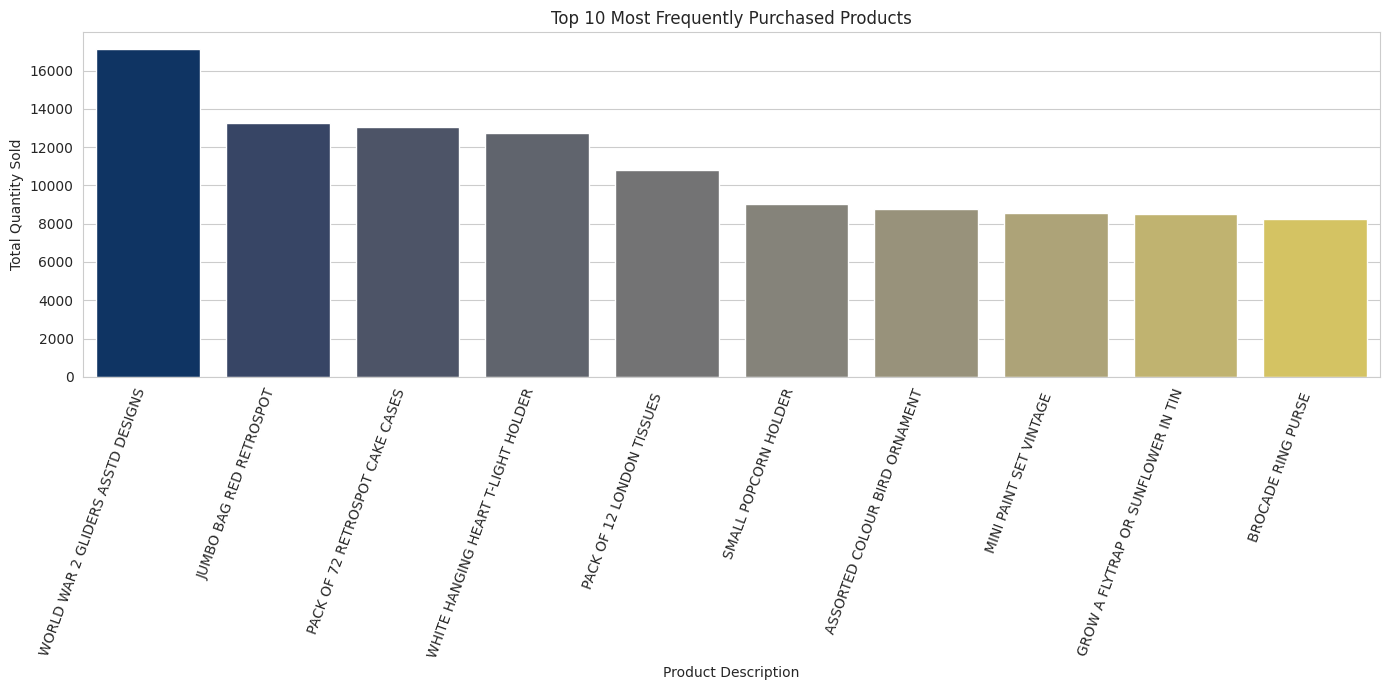

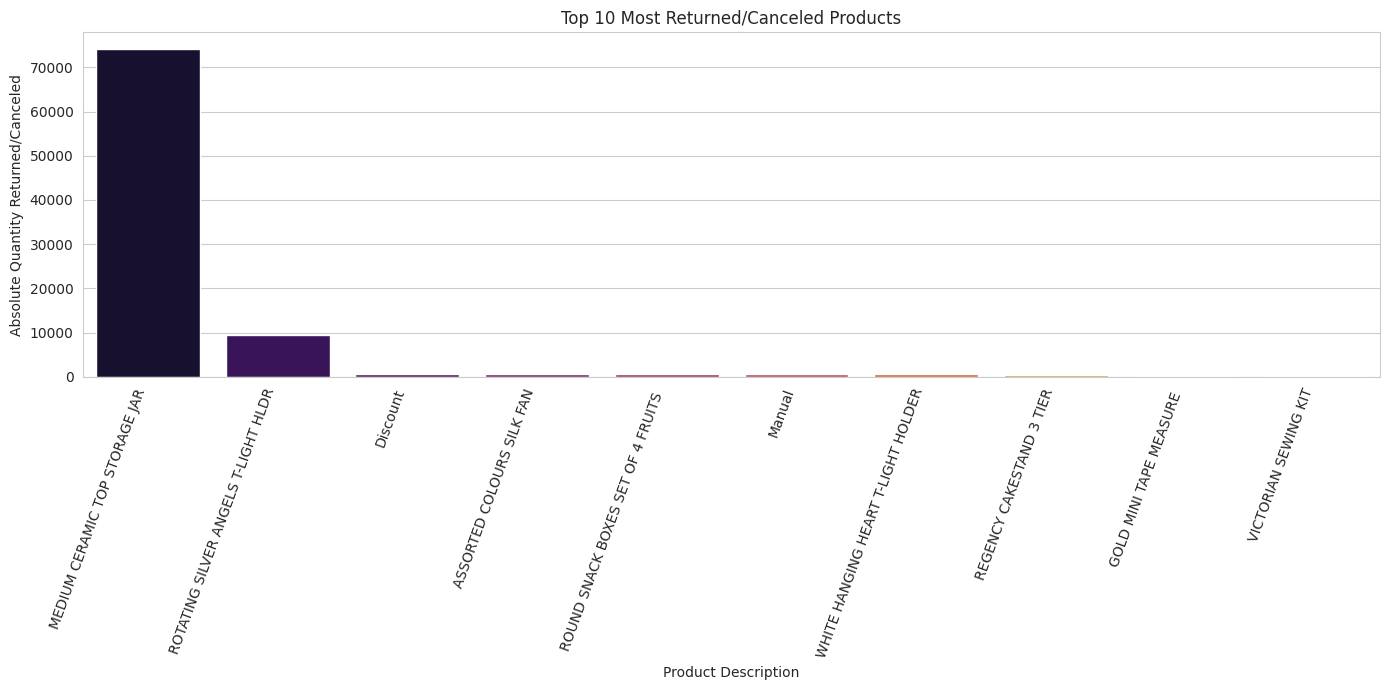

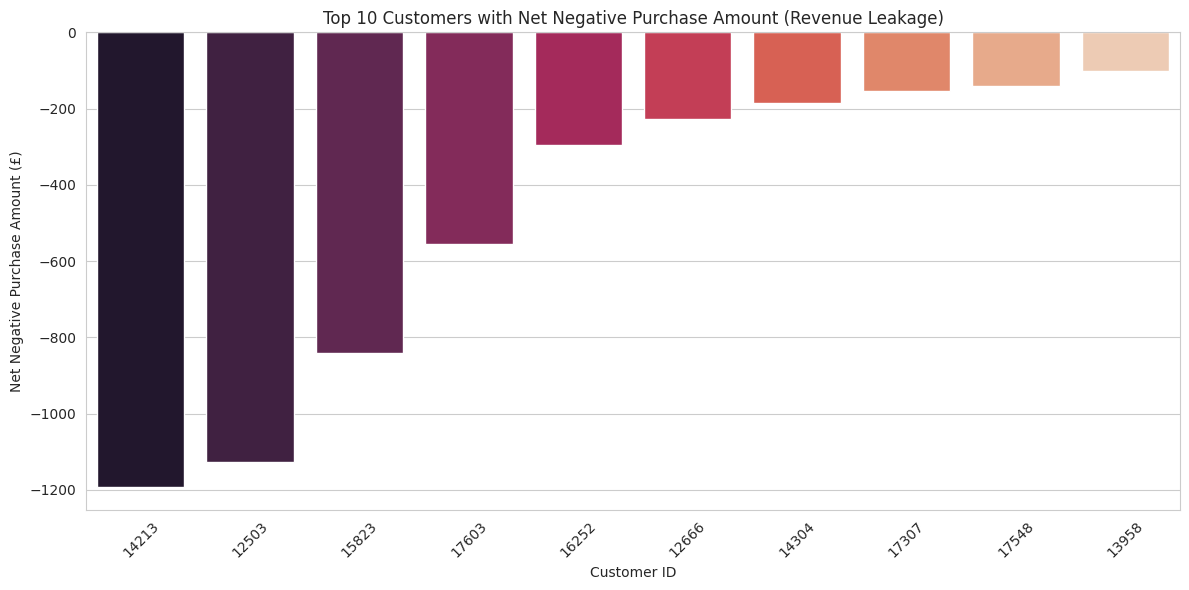

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style("whitegrid")

print("--- Visualizing Key Findings ---")

# 1. Bar plot for the top 10 customers by total purchase amount
plt.figure(figsize=(12, 6))
sns.barplot(x=total_purchase_per_customer.head(10).index.astype(str), y=total_purchase_per_customer.head(10).values, hue=total_purchase_per_customer.head(10).index.astype(str), palette='viridis', legend=False)
plt.title('Top 10 Customers by Total Purchase Amount')
plt.xlabel('Customer ID')
plt.ylabel('Total Purchase Amount (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Bar plot for the top 10 customers by average order value
plt.figure(figsize=(12, 6))
sns.barplot(x=average_order_value_per_customer.head(10).index.astype(str), y=average_order_value_per_customer.head(10).values, hue=average_order_value_per_customer.head(10).index.astype(str), palette='plasma', legend=False)
plt.title('Top 10 Customers by Average Order Value')
plt.xlabel('Customer ID')
plt.ylabel('Average Order Value (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Bar plot for the top 10 customers by purchase frequency
plt.figure(figsize=(12, 6))
sns.barplot(x=purchase_frequency_per_customer.head(10).index.astype(str), y=purchase_frequency_per_customer.head(10).values, hue=purchase_frequency_per_customer.head(10).index.astype(str), palette='magma', legend=False)
plt.title('Top 10 Customers by Purchase Frequency')
plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Bar plot for the top 10 most frequently purchased products
plt.figure(figsize=(14, 7))
sns.barplot(x=popular_products.head(10).index, y=popular_products.head(10).values, hue=popular_products.head(10).index, palette='cividis', legend=False)
plt.title('Top 10 Most Frequently Purchased Products')
plt.xlabel('Product Description')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=70, ha='right') # Rotate for better readability
plt.tight_layout()
plt.show()

# 5. Bar plot for the top 10 most returned/canceled products
plt.figure(figsize=(14, 7))
sns.barplot(x=top_returned_products.head(10).index, y=top_returned_products.head(10).values, hue=top_returned_products.head(10).index, palette='inferno', legend=False)
plt.title('Top 10 Most Returned/Canceled Products')
plt.xlabel('Product Description')
plt.ylabel('Absolute Quantity Returned/Canceled')
plt.xticks(rotation=70, ha='right') # Rotate for better readability
plt.tight_layout()
plt.show()

# 6. Bar plot for the top 10 customers with a net negative total purchase amount
plt.figure(figsize=(12, 6))
sns.barplot(x=customers_net_negative_purchase.head(10).index.astype(str), y=customers_net_negative_purchase.head(10).values, hue=customers_net_negative_purchase.head(10).index.astype(str), palette='rocket', legend=False)
plt.title('Top 10 Customers with Net Negative Purchase Amount (Revenue Leakage)')
plt.xlabel('Customer ID')
plt.ylabel('Net Negative Purchase Amount (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the key insights gained from the analysis of customer purchase behavior and revenue leakage, and suggest actionable recommendations or next steps for further investigation or intervention.


## Summary:

### Data Analysis Key Findings

*   **Data Preparation**: The dataset, initially containing 150,444 entries, required cleaning. It was successfully loaded using `latin1` encoding. Significant missing values were identified, notably 46,504 (`31%`) in `CustomerID` and 598 in `Description`. After removing rows with missing `CustomerID` and converting `InvoiceDate` to datetime objects, the dataset was reduced to 103,940 entries. A `TotalPrice` column was created by multiplying `Quantity` and `UnitPrice`.
*   **Top Customer Segments**:
    *   **Highest Spender**: Customer `14646` had the highest total purchases, amounting to \$81,567.62.
    *   **Highest Average Order Value**: Customer `15749` exhibited the highest average order value, at \$11,499.20.
    *   **Highest Purchase Frequency**: Customer `12748` was the most frequent purchaser, placing 61 unique orders.
*   **Popular Products**: "WORLD WAR 2 GLIDERS ASSTD DESIGNS" was the most popular product by quantity, with 17,140 units sold.
*   **Revenue Leakage from Returns/Cancellations**:
    *   A total of 2,600 transactions with negative quantities were identified as returns or cancellations.
    *   The total monetary value of these returned/canceled items amounted to a significant -\$150,311.42.
    *   "MEDIUM CERAMIC TOP STORAGE JAR" was the most returned/canceled product by quantity, with 74,215 units.
    *   Customer `14213` was identified as having the highest net negative purchase amount, costing the business -\$1,192.20 due to returns exceeding purchases.
*   **Visualization**: Key findings regarding customer behavior and revenue leakage were effectively visualized through various bar plots, enhancing the interpretability of the analysis.

### Insights or Next Steps

*   **Customer Retention and Engagement**: Focus on nurturing high-value customers (e.g., Customer `14646`) and frequent buyers (e.g., Customer `12748`) through loyalty programs or personalized offers. Investigate why customers with high average order values (e.g., Customer `15749`) don't always have high total spend or frequency, to encourage more repeat purchases.
*   **Mitigating Revenue Leakage**: Address the high return rate for products like "MEDIUM CERAMIC TOP STORAGE JAR" by investigating potential quality issues, misleading descriptions, or packaging problems. Implement strategies to manage customers with consistently net negative purchase amounts, such as reviewing return policies or offering product recommendations to reduce future returns.
